# 13 — Best Fusion: Score Fusion + Adaptive Gated Fusion — FULL FIXED

এই notebook আপনার দুই expert combine করবে:

```text
Skeleton expert   = GaitTR
Silhouette expert = GaitGL-style silhouette expert
```

It has two fusion stages:

## Stage A — score-level fusion baseline

Uses saved gallery/probe embeddings from previous evaluation notebooks.

Baselines:

```text
Skeleton-only
Silhouette-only
Fixed score fusion
Condition-guided score fusion
Global alpha search
Per-condition alpha search diagnostic
```

## Stage B — trainable adaptive gated fusion

Uses train/gallery/probe embeddings from both experts. It trains:

```text
1. Concatenation fusion baseline
2. Adaptive scalar-gated fusion
3. Adaptive vector-gated fusion
```

Fusion formula:

```text
F_fused = alpha * F_silhouette + (1 - alpha) * F_skeleton
```

Interpretation:

```text
alpha close to 1 → silhouette boss
alpha close to 0 → skeleton boss
```

Outputs:

```text
results/fusion_gate/
├── score_fusion_results.csv
├── trainable_fusion_results.csv
├── adaptive_gate_alpha_analysis.csv
├── best_fusion_summary.json
├── plots/
└── checkpoints/
```

Important:

- `NUM_WORKERS = 0` is used to avoid Jupyter DataLoader cleanup warnings.
- No `tabulate` dependency is used.
- If train embeddings are not available and skeleton checkpoint loading fails, Stage A will still run if evaluation embeddings are available.

In [1]:
# ============================================================
# CELL 1 — Imports, paths, config
# ============================================================

from pathlib import Path
import os, re, json, time, math, gc, warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

try:
    from tqdm.notebook import tqdm
except Exception:
    try:
        from tqdm import tqdm
    except Exception:
        def tqdm(x, *args, **kwargs):
            return x

warnings.filterwarnings("ignore")

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
DATA_DIR = EXP_DIR / "data"
FUSION_SPLIT_DIR = DATA_DIR / "fusion_splits"
CHECKPOINT_DIR = EXP_DIR / "checkpoints"
RESULT_DIR = EXP_DIR / "results"
LOG_DIR = EXP_DIR / "logs"

FUSION_ROOT = RESULT_DIR / "fusion_gate"
CACHE_DIR = FUSION_ROOT / "expert_embedding_cache"
PLOT_DIR = FUSION_ROOT / "plots"
DETAIL_DIR = FUSION_ROOT / "details"
FUSION_CKPT_DIR = FUSION_ROOT / "checkpoints"

for d in [FUSION_ROOT, CACHE_DIR, PLOT_DIR, DETAIL_DIR, FUSION_CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SPLIT_NAME = "LT"
SEQ_LEN = 60
SIL_H = 64
SIL_W = 44

TRAIN_CSV = FUSION_SPLIT_DIR / f"train_{SPLIT_NAME}_fusion.csv"
GALLERY_CSV = FUSION_SPLIT_DIR / f"gallery_{SPLIT_NAME}_fusion.csv"
PROBE_CSVS = {
    "NM": FUSION_SPLIT_DIR / f"probe_{SPLIT_NAME}_nm_fusion.csv",
    "BG": FUSION_SPLIT_DIR / f"probe_{SPLIT_NAME}_bg_fusion.csv",
    "CL": FUSION_SPLIT_DIR / f"probe_{SPLIT_NAME}_cl_fusion.csv",
}

# Best silhouette checkpoint from notebook 11.
SILHOUETTE_CHECKPOINT = CHECKPOINT_DIR / "gaitgl_LT_silhouette_best_loss.pth"

# Set this to the skeleton checkpoint that produced your best skeleton results.
# If this architecture does not match the optional extractor below, use saved skeleton embeddings from your skeleton evaluation notebook.
SKELETON_CHECKPOINT = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_best_loss.pth"

EXTRACT_MISSING_EXPERT_EMBEDDINGS = True
RUN_SCORE_FUSION = True
RUN_TRAINABLE_FUSION = True

EXCLUDE_IDENTICAL_VIEW = True
TOPK = 10

NUM_EVAL_CLIPS = 5
EXTRACT_BATCH_SIZE = 32
NUM_WORKERS = 0

FUSION_DIM = 256
TRAIN_BATCH_P = 8
TRAIN_BATCH_K = 4
TRAIN_BATCH_SIZE = TRAIN_BATCH_P * TRAIN_BATCH_K

FUSION_MAX_STEPS = 12000
FUSION_STEPS_PER_EPOCH = 300
FUSION_LR = 1e-3
FUSION_WEIGHT_DECAY = 1e-4
FUSION_WARMUP_STEPS = 500

TRIPLET_MARGIN = 0.20
TRIPLET_WEIGHT = 0.30
CE_LABEL_SMOOTHING = 0.05

USE_ALPHA_PRIOR = True
ALPHA_PRIOR_WEIGHT = 0.03
ALPHA_TARGET_BY_CONDITION = {
    "nm": 0.75,
    "bg": 0.65,
    "cl": 0.25,
}

LOG_EVERY = 50
SAVE_EVERY = 1000

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print("=" * 80)
print("Adaptive Fusion Gate — FULL FIXED")
print("=" * 80)
print("EXP_DIR:", EXP_DIR)
print("TRAIN_CSV:", TRAIN_CSV)
print("GALLERY_CSV:", GALLERY_CSV)
print("SILHOUETTE_CHECKPOINT:", SILHOUETTE_CHECKPOINT)
print("SKELETON_CHECKPOINT:", SKELETON_CHECKPOINT)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("=" * 80)

assert TRAIN_CSV.exists(), f"Missing train fusion CSV: {TRAIN_CSV}"
assert GALLERY_CSV.exists(), f"Missing gallery fusion CSV: {GALLERY_CSV}"
for k, p in PROBE_CSVS.items():
    assert p.exists(), f"Missing probe CSV for {k}: {p}"

Adaptive Fusion Gate — FULL FIXED
EXP_DIR: /media/wadud/DriveUbuntu/GaitRecognition 2.0
TRAIN_CSV: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/train_LT_fusion.csv
GALLERY_CSV: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/gallery_LT_fusion.csv
SILHOUETTE_CHECKPOINT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaitgl_LT_silhouette_best_loss.pth
SKELETON_CHECKPOINT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_best_loss.pth
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# ============================================================
# CELL 2 — Load split CSVs and create stable sample keys
# ============================================================

csv_dtype = {
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
    "pose_path": str,
    "silhouette_path": str,
}

def normalize_view(v):
    v = str(v)
    if v.isdigit():
        return f"{int(v):03d}"
    return v

def add_sample_key(df):
    df = df.copy()
    for c in ["subject", "condition", "seq", "view"]:
        df[c] = df[c].astype(str)
    df["view"] = df["view"].apply(normalize_view)
    df["sample_key"] = (
        df["subject"].astype(str) + "-" +
        df["condition"].astype(str) + "-" +
        df["seq"].astype(str) + "-" +
        df["view"].astype(str)
    )
    return df

def load_split_csv(path):
    df = pd.read_csv(path, dtype=csv_dtype)
    needed = ["subject", "condition", "seq", "view"]
    missing = [c for c in needed if c not in df.columns]
    assert not missing, f"{path} missing columns: {missing}"
    df = add_sample_key(df)
    return df

df_train = load_split_csv(TRAIN_CSV)
df_gallery = load_split_csv(GALLERY_CSV)
probe_dfs = {name: load_split_csv(path) for name, path in PROBE_CSVS.items()}

subjects_train = sorted(df_train["subject"].unique().tolist())
subject_to_label = {s: i for i, s in enumerate(subjects_train)}
label_to_subject = {i: s for s, i in subject_to_label.items()}

df_train["label"] = df_train["subject"].map(subject_to_label).astype(int)
num_train_classes = len(subjects_train)

print("Train rows:", len(df_train), "subjects:", num_train_classes)
print("Gallery rows:", len(df_gallery), "subjects:", df_gallery["subject"].nunique())
for name, df in probe_dfs.items():
    print(f"Probe {name}: rows={len(df)}, subjects={df['subject'].nunique()}")

display(df_train.head())

Train rows: 8139 subjects: 74
Gallery rows: 2197 subjects: 50
Probe NM: rows=1100, subjects=50
Probe BG: rows=1100, subjects=50
Probe CL: rows=1100, subjects=50


,split_pose_path,subject,condition,seq,view,pose_path,silhouette_path,T_pose,T_silhouette,T_common,T_diff,alignment_status,sil_valid_frame_ratio,sil_mean_det_score,sil_mean_mask_area,sample_key,label
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99.0,99.0,99.0,0.0,exact,1.000000,0.910541,4039.515137,001-bg-01-000,0
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,102.0,102.0,102.0,0.0,exact,1.000000,0.905187,4417.048828,001-bg-01-018,0
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99.0,99.0,99.0,0.0,exact,0.969697,0.862985,3496.373779,001-bg-01-036,0
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106.0,106.0,106.0,0.0,exact,0.943396,0.839839,2664.773682,001-bg-01-054,0
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106.0,106.0,106.0,0.0,exact,0.811321,0.682147,2239.179199,001-bg-01-072,0


In [3]:
# ============================================================
# CELL 3 — Embedding file utilities and auto-discovery
# ============================================================

def np_load_embedding_file(npz_path):
    npz_path = Path(npz_path)
    data = np.load(npz_path, allow_pickle=True)

    for key in ["embeddings", "embedding", "features", "feature", "emb", "x", "X"]:
        if key in data.files:
            arr = data[key]
            arr = np.asarray(arr, dtype=np.float32)
            return arr

    raise KeyError(f"No embedding array found in {npz_path}. Keys={data.files}")

def find_meta_csv_for_npz(npz_path):
    npz_path = Path(npz_path)
    candidates = [
        npz_path.with_name(npz_path.stem.replace("_embeddings", "_meta") + ".csv"),
        npz_path.with_name(npz_path.stem + "_meta.csv"),
        npz_path.with_suffix(".csv"),
    ]

    for c in candidates:
        if c.exists():
            return c

    stem = npz_path.stem.replace("_embeddings", "")
    found = sorted(npz_path.parent.glob(f"{stem}*meta*.csv"))
    return found[0] if found else None

def normalize_meta_df(meta_df):
    df = meta_df.copy()

    rename = {}
    if "probe_subject" in df.columns and "subject" not in df.columns:
        rename["probe_subject"] = "subject"
    if "probe_condition" in df.columns and "condition" not in df.columns:
        rename["probe_condition"] = "condition"
    if "probe_seq" in df.columns and "seq" not in df.columns:
        rename["probe_seq"] = "seq"
    if "probe_view" in df.columns and "view" not in df.columns:
        rename["probe_view"] = "view"

    df = df.rename(columns=rename)

    needed = ["subject", "condition", "seq", "view"]
    missing = [c for c in needed if c not in df.columns]
    assert not missing, f"Meta CSV missing columns: {missing}; available={list(df.columns)}"

    df = add_sample_key(df)
    return df

def load_embedding_pair(npz_path):
    npz_path = Path(npz_path)
    emb = np_load_embedding_file(npz_path)
    meta_csv = find_meta_csv_for_npz(npz_path)
    assert meta_csv is not None and meta_csv.exists(), f"Meta CSV not found for {npz_path}"
    meta = normalize_meta_df(pd.read_csv(meta_csv, dtype=str))
    assert len(emb) == len(meta), f"Embedding/meta row mismatch: {npz_path} {emb.shape} vs {len(meta)}"
    return emb, meta, meta_csv

def norm_emb(x):
    x = np.asarray(x, dtype=np.float32)
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), 1e-12)

def save_embedding_pair(expert, split_tag, embeddings, meta_df):
    out_npz = CACHE_DIR / f"{expert}_{split_tag}_embeddings.npz"
    out_csv = CACHE_DIR / f"{expert}_{split_tag}_meta.csv"
    np.savez_compressed(out_npz, embeddings=embeddings.astype(np.float32))
    meta_df.to_csv(out_csv, index=False)
    return out_npz, out_csv

def split_tag_from_condition(condition):
    if condition == "gallery":
        return f"gallery_{SPLIT_NAME}"
    if condition == "train":
        return f"train_{SPLIT_NAME}"
    return f"probe_{SPLIT_NAME}_{condition.lower()}"

def find_embedding_npz(expert, split_tag):
    direct = CACHE_DIR / f"{expert}_{split_tag}_embeddings.npz"
    if direct.exists():
        return direct

    if expert == "silhouette":
        base = RESULT_DIR / "gaitgl_silhouette_eval" / "embeddings"
        candidates = [
            base / f"gaitgl_LT_silhouette_best_loss_{split_tag}_embeddings.npz",
            base / f"gaitgl_LT_silhouette_last_{split_tag}_embeddings.npz",
            base / f"gaitgl_LT_silhouette_full_last_{split_tag}_embeddings.npz",
        ]
        for c in candidates:
            if c.exists():
                return c

    split_bits = split_tag.lower().split("_")
    candidates = []

    for p in RESULT_DIR.rglob("*embedding*.npz"):
        s = str(p).lower()

        if expert == "silhouette":
            if not ("silhouette" in s or "gaitgl" in s):
                continue
        else:
            if ("silhouette" in s or "gaitgl" in s):
                continue
            if not ("skeleton" in s or "gaittr" in s or "pose" in s):
                continue

        if all(bit in s for bit in split_bits):
            candidates.append(p)

    candidates = sorted(candidates, key=lambda p: (len(str(p)), str(p)))
    return candidates[0] if candidates else None

def try_load_embedding(expert, split_tag):
    p = find_embedding_npz(expert, split_tag)
    if p is None:
        return None, None, None

    try:
        emb, meta, meta_csv = load_embedding_pair(p)
        print(f"[FOUND] {expert} {split_tag}: {p} shape={emb.shape}")
        return emb, meta, p
    except Exception as e:
        print(f"[FAILED LOAD] {expert} {split_tag}: {p} error={e}")
        return None, None, None

def load_all_available_embeddings():
    out = defaultdict(dict)
    for expert in ["skeleton", "silhouette"]:
        for name in ["train", "gallery", "NM", "BG", "CL"]:
            split_tag = split_tag_from_condition(name)
            emb, meta, path = try_load_embedding(expert, split_tag)
            if emb is not None:
                out[expert][name] = {"emb": emb, "meta": meta, "path": path}
    return out

available_embs = load_all_available_embeddings()

print("\nAvailable embeddings summary:")
for expert, parts in available_embs.items():
    print(expert, ":", list(parts.keys()))

[FOUND] skeleton train_LT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/expert_embedding_cache/skeleton_train_LT_embeddings.npz shape=(8139, 128)
[FOUND] skeleton gallery_LT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/expert_embedding_cache/skeleton_gallery_LT_embeddings.npz shape=(2197, 128)
[FOUND] skeleton probe_LT_nm: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/expert_embedding_cache/skeleton_probe_LT_nm_embeddings.npz shape=(1100, 128)
[FOUND] skeleton probe_LT_bg: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/expert_embedding_cache/skeleton_probe_LT_bg_embeddings.npz shape=(1100, 128)
[FOUND] skeleton probe_LT_cl: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/expert_embedding_cache/skeleton_probe_LT_cl_embeddings.npz shape=(1100, 128)
[FOUND] silhouette train_LT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_train_

In [4]:
# ============================================================
# CELL 4 — Optional silhouette extractor: GaitGL-style backbone
# Used to create missing silhouette train embeddings.
# ============================================================

def make_eval_clips(S, seq_len=60, num_clips=5):
    T = S.shape[0]
    if T <= 0:
        raise ValueError("Empty sequence")

    clips = []

    if T >= seq_len:
        if num_clips <= 1:
            starts = [max(0, (T - seq_len) // 2)]
        else:
            starts = [int(round(x)) for x in np.linspace(0, T - seq_len, num=num_clips)]

        for st in starts:
            clips.append(S[st:st + seq_len])
    else:
        pad = np.repeat(S[-1:], seq_len - T, axis=0)
        clip = np.concatenate([S, pad], axis=0)
        clips = [clip for _ in range(num_clips)]

    return np.stack(clips, axis=0).astype(np.float32)

class ConvBNAct3D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), dropout=0.0):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm3d(out_channels)
        self.act = nn.Mish()
        self.drop = nn.Dropout3d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class Residual3DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=(1, 1, 1), dropout=0.0):
        super().__init__()
        self.conv1 = ConvBNAct3D(in_channels, out_channels, stride=stride, dropout=dropout)
        self.conv2 = nn.Sequential(
            nn.Conv3d(out_channels, out_channels, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False),
            nn.BatchNorm3d(out_channels),
        )
        if in_channels != out_channels or stride != (1, 1, 1):
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm3d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()
        self.act = nn.Mish()

    def forward(self, x):
        return self.act(self.conv2(self.conv1(x)) + self.shortcut(x))

class HorizontalPyramidPooling3D(nn.Module):
    def __init__(self, bins=(1, 2, 4, 8)):
        super().__init__()
        self.bins = list(bins)

    def forward(self, x):
        B, C, T, H, W = x.shape
        parts = []
        for b in self.bins:
            for i in range(b):
                h0 = int(round(i * H / b))
                h1 = max(int(round((i + 1) * H / b)), h0 + 1)
                part = x[:, :, :, h0:h1, :]
                parts.append(part.mean(dim=(2, 3, 4)) + part.amax(dim=(2, 3, 4)))
        return torch.stack(parts, dim=1)

class GaitGLLiteBackbone(nn.Module):
    def __init__(self, embedding_dim=256, channels=(32, 64, 128, 128), hpp_bins=(1, 2, 4, 8), dropout=0.1):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.stem = nn.Sequential(
            ConvBNAct3D(1, c1, kernel_size=(3, 5, 5), padding=(1, 2, 2)),
            Residual3DBlock(c1, c1, dropout=dropout),
        )
        self.layer1 = nn.Sequential(
            Residual3DBlock(c1, c2, stride=(1, 2, 2), dropout=dropout),
            Residual3DBlock(c2, c2, dropout=dropout),
        )
        self.layer2 = nn.Sequential(
            Residual3DBlock(c2, c3, stride=(1, 2, 2), dropout=dropout),
            Residual3DBlock(c3, c3, dropout=dropout),
        )
        self.layer3 = nn.Sequential(
            ConvBNAct3D(c3, c4, dropout=dropout),
            Residual3DBlock(c4, c4, dropout=dropout),
        )
        self.hpp = HorizontalPyramidPooling3D(hpp_bins)
        self.part_norm = nn.LayerNorm(c4)
        self.part_fc = nn.Linear(c4, embedding_dim, bias=False)
        self.embedding_bn = nn.BatchNorm1d(embedding_dim)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        parts = self.hpp(x)
        parts = self.part_norm(parts)
        parts = self.part_fc(parts)
        emb = parts.mean(dim=1)
        emb = self.embedding_bn(emb)
        return F.normalize(emb, p=2, dim=1)

def strip_prefix_state_dict(state, prefix):
    if all(k.startswith(prefix) for k in state.keys()):
        return {k[len(prefix):]: v for k, v in state.items()}
    return state

def load_gaitgl_backbone(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    config = ckpt.get("config", {})
    emb_dim = int(config.get("embedding_dim", 256))
    channels = config.get("channels", [32, 64, 128, 128])
    hpp_bins = config.get("hpp_bins", [1, 2, 4, 8])
    dropout = float(config.get("dropout", 0.1))

    model = GaitGLLiteBackbone(emb_dim, channels, hpp_bins, dropout)

    state = ckpt["model"]
    state = strip_prefix_state_dict(state, "module.")
    if any(k.startswith("backbone.") for k in state.keys()):
        state = {k[len("backbone."):]: v for k, v in state.items() if k.startswith("backbone.")}
    state = {k: v for k, v in state.items() if not k.startswith("classifier.")}

    missing, unexpected = model.load_state_dict(state, strict=False)
    if len(missing) > 0:
        raise RuntimeError(f"GaitGL checkpoint loading missing keys: {missing[:10]}")
    model = model.to(device).eval()
    return model

class SilhouetteRawDataset(Dataset):
    def __init__(self, df, num_clips=5):
        self.df = df.reset_index(drop=True).copy()
        self.num_clips = num_clips

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["silhouette_path"]
        data = np.load(path)
        S = data["silhouettes"].astype(np.float32)
        if S.max() > 1.5:
            S = S / 255.0
        clips = make_eval_clips(S, SEQ_LEN, self.num_clips)
        return {
            "clips": torch.from_numpy(clips),
            "sample_key": row["sample_key"],
            "subject": row["subject"],
            "condition": row["condition"],
            "seq": row["seq"],
            "view": row["view"],
            "silhouette_path": str(path),
        }

@torch.no_grad()
def extract_silhouette_embeddings_for_df(df, split_tag):
    assert SILHOUETTE_CHECKPOINT.exists(), f"Missing silhouette checkpoint: {SILHOUETTE_CHECKPOINT}"
    model = load_gaitgl_backbone(SILHOUETTE_CHECKPOINT)

    ds = SilhouetteRawDataset(df, num_clips=NUM_EVAL_CLIPS)
    dl = DataLoader(ds, batch_size=EXTRACT_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    all_emb = []
    rows = []

    for batch in tqdm(dl, desc=f"Extract silhouette {split_tag}"):
        clips = batch["clips"].float().to(device)
        B, N, T, H, W = clips.shape
        clip_embs = []
        for i in range(N):
            emb = model(clips[:, i])
            clip_embs.append(emb)
        emb = torch.stack(clip_embs, dim=1).mean(dim=1)
        emb = F.normalize(emb, p=2, dim=1)
        all_emb.append(emb.cpu().numpy().astype(np.float32))

        for i in range(B):
            rows.append({
                "sample_key": batch["sample_key"][i],
                "subject": batch["subject"][i],
                "condition": batch["condition"][i],
                "seq": batch["seq"][i],
                "view": batch["view"][i],
                "silhouette_path": batch["silhouette_path"][i],
            })

    emb = np.concatenate(all_emb, axis=0)
    meta = add_sample_key(pd.DataFrame(rows))
    out_npz, out_csv = save_embedding_pair("silhouette", split_tag, emb, meta)
    print("Saved silhouette embeddings:", out_npz, emb.shape)
    return emb, meta, out_npz

In [5]:
# ============================================================
# CELL 5 — Optional skeleton extractor: best-effort GaitTR-like backbone
# If it fails, use skeleton embeddings saved by your skeleton evaluation script.
# ============================================================

def make_pose_eval_clips(X, seq_len=60, num_clips=5):
    T = X.shape[0]
    if T <= 0:
        raise ValueError("Empty pose sequence")

    clips = []
    if T >= seq_len:
        starts = [max(0, (T - seq_len) // 2)] if num_clips <= 1 else [int(round(x)) for x in np.linspace(0, T - seq_len, num=num_clips)]
        for st in starts:
            clips.append(X[st:st + seq_len])
    else:
        pad = np.repeat(X[-1:], seq_len - T, axis=0)
        clip = np.concatenate([X, pad], axis=0)
        clips = [clip for _ in range(num_clips)]
    return np.stack(clips, axis=0).astype(np.float32)

class FlexibleSkeletonTRBackbone(nn.Module):
    def __init__(
        self,
        seq_len=60,
        num_joints=17,
        coord_dim=2,
        d_model=128,
        nhead=4,
        num_layers=4,
        dim_feedforward=256,
        embedding_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.num_joints = num_joints
        self.coord_dim = coord_dim
        self.d_model = d_model

        self.input_proj = nn.Linear(num_joints * coord_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model * 2, embedding_dim, bias=False)
        self.embedding_bn = nn.BatchNorm1d(embedding_dim)

    def forward(self, x):
        B, T, J, C = x.shape
        x = x.reshape(B, T, J * C)
        x = self.input_proj(x)

        if T <= self.pos_embed.shape[1]:
            x = x + self.pos_embed[:, :T]
        else:
            pe = F.interpolate(self.pos_embed.transpose(1, 2), size=T, mode="linear", align_corners=False).transpose(1, 2)
            x = x + pe

        x = self.encoder(x)
        x = self.norm(x)
        mean_pool = x.mean(dim=1)
        max_pool = x.amax(dim=1)
        emb = self.fc(torch.cat([mean_pool, max_pool], dim=1))
        emb = self.embedding_bn(emb)
        return F.normalize(emb, p=2, dim=1)

def get_state_dict_from_checkpoint(path):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(ckpt, dict):
        for k in ["model", "state_dict", "backbone", "net"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                return ckpt[k], ckpt
        if all(isinstance(k, str) for k in ckpt.keys()) and any("weight" in k for k in ckpt.keys()):
            return ckpt, {}
    raise RuntimeError(f"Could not find state_dict inside checkpoint: {path}")

def clean_skeleton_state_dict(state):
    state = dict(state)

    prefixes = ["module.", "model.", "backbone."]
    changed = True
    while changed:
        changed = False
        for pref in prefixes:
            if any(k.startswith(pref) for k in state.keys()):
                new_state = {}
                for k, v in state.items():
                    if k.startswith(pref):
                        new_state[k[len(pref):]] = v
                    else:
                        new_state[k] = v
                state = new_state
                changed = True

    drop_prefixes = ["classifier.", "head.", "id_classifier.", "condition_classifier."]
    state = {k: v for k, v in state.items() if not any(k.startswith(p) for p in drop_prefixes)}
    return state

def infer_skeleton_config_from_state(state):
    d_model = 128
    emb_dim = 256
    num_layers = 4
    nhead = 4
    dim_feedforward = 256

    if "input_proj.weight" in state:
        d_model = int(state["input_proj.weight"].shape[0])

    if "pos_embed" in state:
        seq_len = int(state["pos_embed"].shape[1])
    elif "pos_embedding" in state:
        seq_len = int(state["pos_embedding"].shape[1])
    else:
        seq_len = SEQ_LEN

    if "fc.weight" in state:
        emb_dim = int(state["fc.weight"].shape[0])
        fc_in = int(state["fc.weight"].shape[1])
        if fc_in % 2 == 0:
            d_model = fc_in // 2

    if "embedding_bn.weight" in state:
        emb_dim = int(state["embedding_bn.weight"].shape[0])

    layer_ids = []
    for k in state.keys():
        m = re.search(r"encoder\.layers\.(\d+)\.", k)
        if m:
            layer_ids.append(int(m.group(1)))
    if layer_ids:
        num_layers = max(layer_ids) + 1

    for k in state.keys():
        if "linear1.weight" in k:
            dim_feedforward = int(state[k].shape[0])
            break

    for h in [8, 4, 2, 1]:
        if d_model % h == 0:
            nhead = h
            break

    return {
        "seq_len": seq_len,
        "d_model": d_model,
        "embedding_dim": emb_dim,
        "num_layers": num_layers,
        "nhead": nhead,
        "dim_feedforward": dim_feedforward,
    }

def remap_possible_skeleton_keys(state):
    remap = {}
    for k in list(state.keys()):
        nk = k
        nk = nk.replace("pos_embedding", "pos_embed")
        nk = nk.replace("transformer_encoder.", "encoder.")
        nk = nk.replace("transformer.", "encoder.")
        nk = nk.replace("embed.", "fc.")
        nk = nk.replace("embedding.", "fc.")
        remap[nk] = state[k]
    return remap

def load_flexible_skeleton_backbone(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    state_raw, ckpt = get_state_dict_from_checkpoint(checkpoint_path)
    state = clean_skeleton_state_dict(state_raw)
    state = remap_possible_skeleton_keys(state)
    cfg = infer_skeleton_config_from_state(state)

    model = FlexibleSkeletonTRBackbone(
        seq_len=cfg["seq_len"],
        d_model=cfg["d_model"],
        nhead=cfg["nhead"],
        num_layers=cfg["num_layers"],
        dim_feedforward=cfg["dim_feedforward"],
        embedding_dim=cfg["embedding_dim"],
    )

    missing, unexpected = model.load_state_dict(state, strict=False)

    core_missing = [m for m in missing if not m.startswith("classifier")]
    if len(core_missing) > 0:
        print("Skeleton load missing keys:", core_missing[:30])
        print("Skeleton load unexpected keys:", unexpected[:30])
        raise RuntimeError(
            "FlexibleSkeletonTRBackbone does not match your skeleton checkpoint. "
            "Please use skeleton embeddings saved by your skeleton evaluation notebook, or adapt this extractor."
        )

    model = model.to(device).eval()
    print("Loaded skeleton checkpoint with inferred config:", cfg)
    return model

class SkeletonRawDataset(Dataset):
    def __init__(self, df, num_clips=5):
        self.df = df.reset_index(drop=True).copy()
        self.num_clips = num_clips

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["pose_path"]
        data = np.load(path)

        if "keypoints_norm_filled" in data.files:
            X = data["keypoints_norm_filled"].astype(np.float32)
        elif "keypoints_norm" in data.files:
            X = data["keypoints_norm"].astype(np.float32)
        elif "keypoints" in data.files:
            X = data["keypoints"].astype(np.float32)
        else:
            raise KeyError(f"No keypoints array found in {path}. Keys={data.files}")

        if X.ndim == 2 and X.shape[1] == 34:
            X = X.reshape(X.shape[0], 17, 2)

        clips = make_pose_eval_clips(X, SEQ_LEN, self.num_clips)

        return {
            "clips": torch.from_numpy(clips),
            "sample_key": row["sample_key"],
            "subject": row["subject"],
            "condition": row["condition"],
            "seq": row["seq"],
            "view": row["view"],
            "pose_path": str(path),
        }

@torch.no_grad()
def extract_skeleton_embeddings_for_df(df, split_tag):
    assert SKELETON_CHECKPOINT.exists(), f"Missing skeleton checkpoint: {SKELETON_CHECKPOINT}"
    model = load_flexible_skeleton_backbone(SKELETON_CHECKPOINT)

    ds = SkeletonRawDataset(df, num_clips=NUM_EVAL_CLIPS)
    dl = DataLoader(ds, batch_size=EXTRACT_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    all_emb = []
    rows = []

    for batch in tqdm(dl, desc=f"Extract skeleton {split_tag}"):
        clips = batch["clips"].float().to(device)
        B, N, T, J, C = clips.shape
        clip_embs = []
        for i in range(N):
            emb = model(clips[:, i])
            clip_embs.append(emb)
        emb = torch.stack(clip_embs, dim=1).mean(dim=1)
        emb = F.normalize(emb, p=2, dim=1)
        all_emb.append(emb.cpu().numpy().astype(np.float32))

        for i in range(B):
            rows.append({
                "sample_key": batch["sample_key"][i],
                "subject": batch["subject"][i],
                "condition": batch["condition"][i],
                "seq": batch["seq"][i],
                "view": batch["view"][i],
                "pose_path": batch["pose_path"][i],
            })

    emb = np.concatenate(all_emb, axis=0)
    meta = add_sample_key(pd.DataFrame(rows))
    out_npz, out_csv = save_embedding_pair("skeleton", split_tag, emb, meta)
    print("Saved skeleton embeddings:", out_npz, emb.shape)
    return emb, meta, out_npz

In [6]:
# ============================================================
# CELL 6 — Create missing expert embeddings if possible
# ============================================================

split_to_df = {
    "train": df_train,
    "gallery": df_gallery,
    "NM": probe_dfs["NM"],
    "BG": probe_dfs["BG"],
    "CL": probe_dfs["CL"],
}

def maybe_extract_missing_embeddings():
    global available_embs

    if not EXTRACT_MISSING_EXPERT_EMBEDDINGS:
        print("EXTRACT_MISSING_EXPERT_EMBEDDINGS=False, skipping extraction.")
        return

    for name, df in split_to_df.items():
        split_tag = split_tag_from_condition(name)
        if name not in available_embs.get("silhouette", {}):
            try:
                emb, meta, path = extract_silhouette_embeddings_for_df(df, split_tag)
                available_embs["silhouette"][name] = {"emb": emb, "meta": meta, "path": path}
            except Exception as e:
                print(f"[WARNING] Could not extract silhouette {name}: {e}")

    for name, df in split_to_df.items():
        split_tag = split_tag_from_condition(name)
        if name not in available_embs.get("skeleton", {}):
            try:
                emb, meta, path = extract_skeleton_embeddings_for_df(df, split_tag)
                available_embs["skeleton"][name] = {"emb": emb, "meta": meta, "path": path}
            except Exception as e:
                print(f"[WARNING] Could not extract skeleton {name}: {e}")
                print("          If needed, save skeleton embeddings using your 06/07 skeleton evaluation notebook.")
                break

maybe_extract_missing_embeddings()

print("\nFinal available embeddings:")
for expert in ["skeleton", "silhouette"]:
    print(expert, list(available_embs.get(expert, {}).keys()))


Final available embeddings:
skeleton ['train', 'gallery', 'NM', 'BG', 'CL']
silhouette ['train', 'gallery', 'NM', 'BG', 'CL']


In [11]:
# ============================================================
# CELL 7 — Alignment utilities for paired skeleton/silhouette embeddings
# ============================================================

def align_two_modalities(skel_emb, skel_meta, sil_emb, sil_meta, required_keys=None):
    skel_meta = normalize_meta_df(skel_meta)
    sil_meta = normalize_meta_df(sil_meta)

    skel_df = skel_meta.reset_index().rename(columns={"index": "skel_idx"})
    sil_df = sil_meta.reset_index().rename(columns={"index": "sil_idx"})

    merged = pd.merge(
        skel_df,
        sil_df[["sample_key", "sil_idx"]],
        on="sample_key",
        how="inner",
    )

    if required_keys is not None:
        key_set = set(required_keys)
        merged = merged[merged["sample_key"].isin(key_set)].copy()

    merged = merged.sort_values(["subject", "condition", "seq", "view"]).reset_index(drop=True)

    sk_idx = merged["skel_idx"].values.astype(int)
    si_idx = merged["sil_idx"].values.astype(int)

    X_skel = norm_emb(skel_emb[sk_idx])
    X_sil = norm_emb(sil_emb[si_idx])

    meta = skel_meta.iloc[sk_idx].reset_index(drop=True).copy()
    meta = add_sample_key(meta)

    assert len(X_skel) == len(X_sil) == len(meta)
    return X_skel, X_sil, meta

def get_aligned_split(name):
    if name not in available_embs.get("skeleton", {}) or name not in available_embs.get("silhouette", {}):
        return None

    sk = available_embs["skeleton"][name]
    si = available_embs["silhouette"][name]

    Xs, Xi, meta = align_two_modalities(sk["emb"], sk["meta"], si["emb"], si["meta"])

    print(f"Aligned {name}: skeleton={Xs.shape}, silhouette={Xi.shape}, rows={len(meta)}")
    return {"skel": Xs, "sil": Xi, "meta": meta}

aligned = {}
for name in ["train", "gallery", "NM", "BG", "CL"]:
    out = get_aligned_split(name)
    if out is not None:
        aligned[name] = out

print("Aligned splits:", list(aligned.keys()))

Aligned train: skeleton=(0, 128), silhouette=(0, 256), rows=0
Aligned gallery: skeleton=(2197, 128), silhouette=(2197, 256), rows=2197
Aligned NM: skeleton=(1100, 128), silhouette=(1100, 256), rows=1100
Aligned BG: skeleton=(1100, 128), silhouette=(1100, 256), rows=1100
Aligned CL: skeleton=(1100, 128), silhouette=(1100, 256), rows=1100
Aligned splits: ['train', 'gallery', 'NM', 'BG', 'CL']


In [12]:
# ============================================================
# FIX CELL — Diagnose and repair empty train alignment
# ============================================================

def show_keys_debug(name):
    print("=" * 80)
    print("DEBUG:", name)
    print("=" * 80)

    if name in available_embs.get("skeleton", {}):
        sm = available_embs["skeleton"][name]["meta"]
        print("Skeleton rows:", len(sm))
        print("Skeleton sample_key head:")
        display(sm[["subject", "condition", "seq", "view", "sample_key"]].head())
    else:
        print("Skeleton missing:", name)

    if name in available_embs.get("silhouette", {}):
        im = available_embs["silhouette"][name]["meta"]
        print("Silhouette rows:", len(im))
        print("Silhouette sample_key head:")
        display(im[["subject", "condition", "seq", "view", "sample_key"]].head())
    else:
        print("Silhouette missing:", name)

show_keys_debug("train")

# Check current train overlap
sk_train_keys = set(available_embs["skeleton"]["train"]["meta"]["sample_key"].astype(str))
si_train_keys = set(available_embs["silhouette"]["train"]["meta"]["sample_key"].astype(str)) if "train" in available_embs.get("silhouette", {}) else set()

print("Skeleton train keys:", len(sk_train_keys))
print("Silhouette train keys:", len(si_train_keys))
print("Overlap train keys:", len(sk_train_keys & si_train_keys))

# If overlap is zero, force regenerate silhouette train embeddings from raw fusion CSV
if len(sk_train_keys & si_train_keys) == 0:
    print("No train overlap found. Re-extracting silhouette train embeddings from df_train...")

    # Remove wrong/old cached silhouette train files if they exist
    bad_npz = CACHE_DIR / f"silhouette_train_{SPLIT_NAME}_embeddings.npz"
    bad_csv = CACHE_DIR / f"silhouette_train_{SPLIT_NAME}_meta.csv"

    if bad_npz.exists():
        bad_npz.unlink()
        print("Deleted:", bad_npz)

    if bad_csv.exists():
        bad_csv.unlink()
        print("Deleted:", bad_csv)

    emb, meta, path = extract_silhouette_embeddings_for_df(
        df_train,
        split_tag=f"train_{SPLIT_NAME}"
    )

    available_embs["silhouette"]["train"] = {
        "emb": emb,
        "meta": meta,
        "path": path,
    }

    print("Re-extracted silhouette train:", emb.shape)

# Rebuild train alignment
out = get_aligned_split("train")

if out is None or len(out["meta"]) == 0:
    raise RuntimeError("Train alignment is still empty. Check sample_key formatting.")

aligned["train"] = out

print("Fixed aligned train rows:", len(aligned["train"]["meta"]))
print("Train subjects:", aligned["train"]["meta"]["subject"].nunique())
display(aligned["train"]["meta"][["subject", "condition", "seq", "view", "sample_key"]].head())

DEBUG: train
Skeleton rows: 8139
Skeleton sample_key head:


,subject,condition,seq,view,sample_key
0,001,bg,01,000,001-bg-01-000
1,001,bg,01,018,001-bg-01-018
2,001,bg,01,036,001-bg-01-036
3,001,bg,01,054,001-bg-01-054
4,001,bg,01,072,001-bg-01-072


Silhouette rows: 2197
Silhouette sample_key head:


,subject,condition,seq,view,sample_key
0,075,nm,01,000,075-nm-01-000
1,075,nm,01,018,075-nm-01-018
2,075,nm,01,036,075-nm-01-036
3,075,nm,01,054,075-nm-01-054
4,075,nm,01,072,075-nm-01-072


Skeleton train keys: 8139
Silhouette train keys: 2197
Overlap train keys: 0
No train overlap found. Re-extracting silhouette train embeddings from df_train...


Extract silhouette train_LT:   0%|          | 0/255 [00:00<?, ?it/s]

Saved silhouette embeddings: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/expert_embedding_cache/silhouette_train_LT_embeddings.npz (8139, 256)
Re-extracted silhouette train: (8139, 256)
Aligned train: skeleton=(8139, 128), silhouette=(8139, 256), rows=8139
Fixed aligned train rows: 8139
Train subjects: 74


,subject,condition,seq,view,sample_key
0,001,bg,01,000,001-bg-01-000
1,001,bg,01,018,001-bg-01-018
2,001,bg,01,036,001-bg-01-036
3,001,bg,01,054,001-bg-01-054
4,001,bg,01,072,001-bg-01-072


In [13]:
# ============================================================
# CELL 8 — Retrieval evaluation functions
# ============================================================

def compute_retrieval_metrics(gallery_emb, gallery_meta, probe_emb, probe_meta, condition_name, method_name, topk=10):
    gallery_emb = norm_emb(gallery_emb)
    probe_emb = norm_emb(probe_emb)

    gallery_meta = normalize_meta_df(gallery_meta)
    probe_meta = normalize_meta_df(probe_meta)

    g_sub = gallery_meta["subject"].astype(str).values
    g_view = gallery_meta["view"].astype(str).values

    p_sub = probe_meta["subject"].astype(str).values
    p_view = probe_meta["view"].astype(str).values

    sim = probe_emb @ gallery_emb.T

    hits = np.zeros(topk, dtype=np.float64)
    detail_rows = []
    valid_queries = 0

    for i in range(len(probe_meta)):
        scores = sim[i].copy()

        if EXCLUDE_IDENTICAL_VIEW:
            invalid = g_view == p_view[i]
            scores[invalid] = -1e9

        if np.sum(scores > -1e8) == 0:
            continue

        ranked = np.argsort(-scores)
        ranked = ranked[:min(topk, len(ranked))]

        ranked_subjects = g_sub[ranked]
        correct = ranked_subjects == p_sub[i]

        rank = np.nan
        if correct.any():
            rank = int(np.where(correct)[0][0]) + 1
            for k in range(rank - 1, topk):
                hits[k] += 1.0

        valid_queries += 1

        top1_idx = ranked[0]
        detail_rows.append({
            "method": method_name,
            "condition": condition_name,
            "probe_index": i,
            "probe_subject": p_sub[i],
            "probe_condition": probe_meta.iloc[i]["condition"],
            "probe_seq": probe_meta.iloc[i]["seq"],
            "probe_view": p_view[i],
            "rank1_correct": bool(correct[0]),
            "rank": rank,
            "top1_subject": g_sub[top1_idx],
            "top1_view": g_view[top1_idx],
            "top1_score": float(scores[top1_idx]),
            "probe_sample_key": probe_meta.iloc[i]["sample_key"],
        })

    cmc = hits / max(valid_queries, 1)
    details = pd.DataFrame(detail_rows)

    summary = {
        "method": method_name,
        "condition": condition_name,
        "num_gallery": int(len(gallery_meta)),
        "num_probe": int(len(probe_meta)),
        "valid_queries": int(valid_queries),
        "rank1": float(cmc[0]) if topk >= 1 else np.nan,
        "rank5": float(cmc[4]) if topk >= 5 else np.nan,
        "rank10": float(cmc[9]) if topk >= 10 else np.nan,
        "rank1_percent": float(cmc[0] * 100.0) if topk >= 1 else np.nan,
        "rank5_percent": float(cmc[4] * 100.0) if topk >= 5 else np.nan,
        "rank10_percent": float(cmc[9] * 100.0) if topk >= 10 else np.nan,
    }

    return summary, cmc, details

def evaluate_method_over_conditions(gallery_emb, gallery_meta, probe_by_condition, method_name):
    summaries = []
    details_all = []
    cmc_by_cond = {}

    for cond, (probe_emb, probe_meta) in probe_by_condition.items():
        s, cmc, d = compute_retrieval_metrics(
            gallery_emb=gallery_emb,
            gallery_meta=gallery_meta,
            probe_emb=probe_emb,
            probe_meta=probe_meta,
            condition_name=cond,
            method_name=method_name,
            topk=TOPK,
        )
        summaries.append(s)
        details_all.append(d)
        cmc_by_cond[cond] = cmc
        print(f"{method_name} {cond}: Rank-1={s['rank1_percent']:.2f}, Rank-5={s['rank5_percent']:.2f}, Rank-10={s['rank10_percent']:.2f}")

    summary_df = pd.DataFrame(summaries)
    summary_df["mean_rank1_percent"] = summary_df["rank1_percent"].mean()
    detail_df = pd.concat(details_all, ignore_index=True) if details_all else pd.DataFrame()

    return summary_df, detail_df, cmc_by_cond

In [14]:
# ============================================================
# CELL 9 — Stage A: Score-level fusion baselines
# ============================================================

score_results = []
score_details = []

def has_eval_embeddings():
    return all(k in aligned for k in ["gallery", "NM", "BG", "CL"])

def score_fuse_similarity(skel_gallery, skel_probe, sil_gallery, sil_probe, alpha):
    skel_sim = norm_emb(skel_probe) @ norm_emb(skel_gallery).T
    sil_sim = norm_emb(sil_probe) @ norm_emb(sil_gallery).T
    return (1.0 - alpha) * skel_sim + alpha * sil_sim

def compute_metrics_from_similarity(sim, gallery_meta, probe_meta, condition_name, method_name, topk=10):
    gallery_meta = normalize_meta_df(gallery_meta)
    probe_meta = normalize_meta_df(probe_meta)

    g_sub = gallery_meta["subject"].astype(str).values
    g_view = gallery_meta["view"].astype(str).values
    p_sub = probe_meta["subject"].astype(str).values
    p_view = probe_meta["view"].astype(str).values

    hits = np.zeros(topk, dtype=np.float64)
    rows = []
    valid_queries = 0

    for i in range(len(probe_meta)):
        scores = sim[i].copy()
        if EXCLUDE_IDENTICAL_VIEW:
            scores[g_view == p_view[i]] = -1e9

        if np.sum(scores > -1e8) == 0:
            continue

        ranked = np.argsort(-scores)[:topk]
        correct = g_sub[ranked] == p_sub[i]

        rank = np.nan
        if correct.any():
            rank = int(np.where(correct)[0][0]) + 1
            for k in range(rank - 1, topk):
                hits[k] += 1.0

        valid_queries += 1
        rows.append({
            "method": method_name,
            "condition": condition_name,
            "probe_subject": p_sub[i],
            "probe_view": p_view[i],
            "rank1_correct": bool(correct[0]),
            "rank": rank,
            "top1_subject": g_sub[ranked[0]],
            "top1_view": g_view[ranked[0]],
            "top1_score": float(scores[ranked[0]]),
            "probe_sample_key": probe_meta.iloc[i]["sample_key"],
        })

    cmc = hits / max(valid_queries, 1)
    summary = {
        "method": method_name,
        "condition": condition_name,
        "alpha": np.nan,
        "rank1_percent": float(cmc[0] * 100.0),
        "rank5_percent": float(cmc[4] * 100.0) if topk >= 5 else np.nan,
        "rank10_percent": float(cmc[9] * 100.0) if topk >= 10 else np.nan,
        "num_gallery": int(len(gallery_meta)),
        "num_probe": int(len(probe_meta)),
        "valid_queries": int(valid_queries),
    }
    return summary, cmc, pd.DataFrame(rows)

def evaluate_score_fusion_alpha(alpha_by_condition, method_name):
    rows = []
    details = []
    cmc_map = {}

    Gs = aligned["gallery"]["skel"]
    Gi = aligned["gallery"]["sil"]
    Gm = aligned["gallery"]["meta"]

    for cond in ["NM", "BG", "CL"]:
        Ps = aligned[cond]["skel"]
        Pi = aligned[cond]["sil"]
        Pm = aligned[cond]["meta"]
        alpha = float(alpha_by_condition[cond])

        sim = score_fuse_similarity(Gs, Ps, Gi, Pi, alpha)
        s, cmc, d = compute_metrics_from_similarity(sim, Gm, Pm, cond, method_name, TOPK)
        s["alpha"] = alpha

        rows.append(s)
        details.append(d)
        cmc_map[cond] = cmc

    df = pd.DataFrame(rows)
    df["mean_rank1_percent"] = df["rank1_percent"].mean()
    detail_df = pd.concat(details, ignore_index=True)

    return df, detail_df, cmc_map

if RUN_SCORE_FUSION and has_eval_embeddings():
    print("Running Stage A — score-level fusion baselines")

    skel_probe = {c: (aligned[c]["skel"], aligned[c]["meta"]) for c in ["NM", "BG", "CL"]}
    df_skel, det_skel, cmc_skel = evaluate_method_over_conditions(
        aligned["gallery"]["skel"], aligned["gallery"]["meta"], skel_probe, "skeleton_only_from_embeddings"
    )
    score_results.append(df_skel)
    score_details.append(det_skel)

    sil_probe = {c: (aligned[c]["sil"], aligned[c]["meta"]) for c in ["NM", "BG", "CL"]}
    df_sil, det_sil, cmc_sil = evaluate_method_over_conditions(
        aligned["gallery"]["sil"], aligned["gallery"]["meta"], sil_probe, "silhouette_only_from_embeddings"
    )
    score_results.append(df_sil)
    score_details.append(det_sil)

    df_avg, det_avg, cmc_avg = evaluate_score_fusion_alpha(
        {"NM": 0.5, "BG": 0.5, "CL": 0.5},
        "score_fusion_fixed_alpha_0p5"
    )
    score_results.append(df_avg)
    score_details.append(det_avg)

    df_guided, det_guided, cmc_guided = evaluate_score_fusion_alpha(
        {"NM": 0.70, "BG": 0.70, "CL": 0.30},
        "score_fusion_condition_guided"
    )
    score_results.append(df_guided)
    score_details.append(det_guided)

    global_alpha_rows = []
    for alpha in np.linspace(0.0, 1.0, 21):
        df_alpha, _, _ = evaluate_score_fusion_alpha(
            {"NM": alpha, "BG": alpha, "CL": alpha},
            f"score_fusion_global_alpha_{alpha:.2f}"
        )
        global_alpha_rows.append({
            "alpha": float(alpha),
            "mean_rank1_percent": float(df_alpha["rank1_percent"].mean()),
            "NM": float(df_alpha[df_alpha["condition"] == "NM"]["rank1_percent"].iloc[0]),
            "BG": float(df_alpha[df_alpha["condition"] == "BG"]["rank1_percent"].iloc[0]),
            "CL": float(df_alpha[df_alpha["condition"] == "CL"]["rank1_percent"].iloc[0]),
        })

    df_alpha_search = pd.DataFrame(global_alpha_rows)
    best_global_alpha = float(df_alpha_search.sort_values("mean_rank1_percent", ascending=False).iloc[0]["alpha"])

    df_best_global, det_best_global, cmc_best_global = evaluate_score_fusion_alpha(
        {"NM": best_global_alpha, "BG": best_global_alpha, "CL": best_global_alpha},
        f"score_fusion_best_global_alpha_{best_global_alpha:.2f}"
    )
    score_results.append(df_best_global)
    score_details.append(det_best_global)

    best_alpha_by_cond = {}
    per_cond_alpha_rows = []
    for cond in ["NM", "BG", "CL"]:
        best_acc = -1
        best_alpha = 0.5
        for alpha in np.linspace(0.0, 1.0, 21):
            alpha_map = {"NM": 0.5, "BG": 0.5, "CL": 0.5}
            alpha_map[cond] = alpha
            df_tmp, _, _ = evaluate_score_fusion_alpha(alpha_map, "tmp")
            acc = float(df_tmp[df_tmp["condition"] == cond]["rank1_percent"].iloc[0])
            if acc > best_acc:
                best_acc = acc
                best_alpha = float(alpha)
        best_alpha_by_cond[cond] = best_alpha
        per_cond_alpha_rows.append({"condition": cond, "best_alpha": best_alpha, "best_rank1_percent": best_acc})

    df_per_cond_alpha = pd.DataFrame(per_cond_alpha_rows)
    df_per_cond_oracle, det_per_cond_oracle, cmc_per_cond_oracle = evaluate_score_fusion_alpha(
        best_alpha_by_cond,
        "score_fusion_per_condition_alpha_diagnostic"
    )
    score_results.append(df_per_cond_oracle)
    score_details.append(det_per_cond_oracle)

    score_results_df = pd.concat(score_results, ignore_index=True)
    score_details_df = pd.concat(score_details, ignore_index=True)

    score_results_csv = FUSION_ROOT / "score_fusion_results.csv"
    score_details_csv = DETAIL_DIR / "score_fusion_probe_details.csv"
    alpha_search_csv = FUSION_ROOT / "score_fusion_global_alpha_search.csv"
    per_cond_alpha_csv = FUSION_ROOT / "score_fusion_per_condition_alpha_search.csv"

    score_results_df.to_csv(score_results_csv, index=False)
    score_details_df.to_csv(score_details_csv, index=False)
    df_alpha_search.to_csv(alpha_search_csv, index=False)
    df_per_cond_alpha.to_csv(per_cond_alpha_csv, index=False)

    print("\nScore fusion results:")
    display(score_results_df[["method", "condition", "alpha", "rank1_percent", "rank5_percent", "rank10_percent", "mean_rank1_percent"]])

    print("Best global alpha:", best_global_alpha)
    display(df_alpha_search.sort_values("mean_rank1_percent", ascending=False).head())

    print("Per-condition alpha diagnostic:")
    display(df_per_cond_alpha)

    print("Saved:", score_results_csv)
else:
    print("Stage A skipped: evaluation embeddings for skeleton and silhouette are not fully available.")
    print("Available aligned splits:", list(aligned.keys()))

Running Stage A — score-level fusion baselines
skeleton_only_from_embeddings NM: Rank-1=95.00, Rank-5=97.18, Rank-10=98.36
skeleton_only_from_embeddings BG: Rank-1=78.64, Rank-5=88.82, Rank-10=92.00
skeleton_only_from_embeddings CL: Rank-1=74.18, Rank-5=86.27, Rank-10=91.36
silhouette_only_from_embeddings NM: Rank-1=97.55, Rank-5=99.36, Rank-10=99.73
silhouette_only_from_embeddings BG: Rank-1=85.45, Rank-5=94.27, Rank-10=96.09
silhouette_only_from_embeddings CL: Rank-1=65.91, Rank-5=83.00, Rank-10=89.00

Score fusion results:


,method,condition,alpha,rank1_percent,rank5_percent,rank10_percent,mean_rank1_percent
0,skeleton_only_from_embeddings,NM,NaN,95.000000,97.181818,98.363636,82.606061
1,skeleton_only_from_embeddings,BG,NaN,78.636364,88.818182,92.000000,82.606061
2,skeleton_only_from_embeddings,CL,NaN,74.181818,86.272727,91.363636,82.606061
3,silhouette_only_from_embeddings,NM,NaN,97.545455,99.363636,99.727273,82.969697
4,silhouette_only_from_embeddings,BG,NaN,85.454545,94.272727,96.090909,82.969697
5,silhouette_only_from_embeddings,CL,NaN,65.909091,83.000000,89.000000,82.969697
6,score_fusion_fixed_alpha_0p5,NM,0.50,99.363636,99.909091,100.000000,95.727273
7,score_fusion_fixed_alpha_0p5,BG,0.50,95.909091,98.636364,98.909091,95.727273
8,score_fusion_fixed_alpha_0p5,CL,0.50,91.909091,97.090909,98.272727,95.727273
9,score_fusion_condition_guided,NM,0.70,99.636364,99.909091,99.909091,94.878788


Best global alpha: 0.5


,alpha,mean_rank1_percent,NM,BG,CL
10,0.50,95.727273,99.363636,95.909091,91.909091
9,0.45,95.666667,99.363636,95.727273,91.909091
11,0.55,95.606061,99.272727,96.090909,91.454545
12,0.60,95.515152,99.363636,96.090909,91.090909
13,0.65,95.393939,99.636364,95.727273,90.818182


Per-condition alpha diagnostic:


,condition,best_alpha,best_rank1_percent
0,NM,0.65,99.636364
1,BG,0.55,96.090909
2,CL,0.45,91.909091


Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/score_fusion_results.csv


In [10]:
# ============================================================
# CELL 10 — Stage B dataset and PK sampler for trainable fusion
# ============================================================

def trainable_ready():
    return all(k in aligned for k in ["train", "gallery", "NM", "BG", "CL"])

class FusionEmbeddingDataset(Dataset):
    def __init__(self, skel_emb, sil_emb, meta_df, subject_to_label):
        self.skel = norm_emb(skel_emb).astype(np.float32)
        self.sil = norm_emb(sil_emb).astype(np.float32)
        self.meta = normalize_meta_df(meta_df).reset_index(drop=True)
        self.subject_to_label = subject_to_label

        self.labels = self.meta["subject"].map(subject_to_label).astype(int).values
        self.cond_id = self.meta["condition"].map({"nm": 0, "bg": 1, "cl": 2}).fillna(-1).astype(int).values

        assert len(self.skel) == len(self.sil) == len(self.meta)

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        return {
            "skel": torch.from_numpy(self.skel[idx]),
            "sil": torch.from_numpy(self.sil[idx]),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long),
            "condition_id": torch.tensor(int(self.cond_id[idx]), dtype=torch.long),
            "condition": str(self.meta.iloc[idx]["condition"]),
            "subject": str(self.meta.iloc[idx]["subject"]),
            "sample_key": str(self.meta.iloc[idx]["sample_key"]),
        }

class PKSampler(Sampler):
    def __init__(self, labels, p=8, k=4, steps_per_epoch=300):
        self.labels = np.asarray(labels)
        self.p = p
        self.k = k
        self.steps_per_epoch = steps_per_epoch

        self.label_to_indices = defaultdict(list)
        for i, lab in enumerate(self.labels):
            self.label_to_indices[int(lab)].append(i)

        self.unique_labels = sorted(self.label_to_indices.keys())
        assert len(self.unique_labels) >= p, f"Need at least {p} identities, found {len(self.unique_labels)}"

    def __len__(self):
        return self.steps_per_epoch

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            labs = np.random.choice(self.unique_labels, size=self.p, replace=False).tolist()
            batch = []
            for lab in labs:
                indices = self.label_to_indices[lab]
                replace = len(indices) < self.k
                chosen = np.random.choice(indices, size=self.k, replace=replace).tolist()
                batch.extend(chosen)
            np.random.shuffle(batch)
            yield batch

def make_train_loader():
    train = aligned["train"]
    ds = FusionEmbeddingDataset(train["skel"], train["sil"], train["meta"], subject_to_label)
    sampler = PKSampler(ds.labels, p=TRAIN_BATCH_P, k=TRAIN_BATCH_K, steps_per_epoch=FUSION_STEPS_PER_EPOCH)
    dl = DataLoader(ds, batch_sampler=sampler, num_workers=0, pin_memory=True)
    return ds, dl

if trainable_ready():
    train_ds, train_dl = make_train_loader()
    batch = next(iter(train_dl))
    print("Train fusion batch skeleton:", batch["skel"].shape)
    print("Train fusion batch silhouette:", batch["sil"].shape)
    print("Trainable fusion is ready.")
else:
    print("Trainable fusion is not ready.")
    print("Required aligned splits: train, gallery, NM, BG, CL")
    print("Available:", list(aligned.keys()))

    missing_readme = FUSION_ROOT / "missing_train_embeddings_README.md"
    missing_readme.write_text(
        "# Missing expert embeddings for trainable fusion\n\n"
        "Trainable adaptive fusion needs paired skeleton and silhouette embeddings for:\n\n"
        "- train_LT_fusion.csv\n"
        "- gallery_LT_fusion.csv\n"
        "- probe_LT_nm_fusion.csv\n"
        "- probe_LT_bg_fusion.csv\n"
        "- probe_LT_cl_fusion.csv\n\n"
        "Silhouette embeddings can usually be extracted by this notebook.\n"
        "If skeleton extraction failed, save skeleton embeddings from your skeleton evaluation notebook, "
        "or adapt the FlexibleSkeletonTRBackbone class to your exact GaitTR checkpoint.\n",
        encoding="utf-8",
    )
    print("Saved:", missing_readme)

AssertionError: Need at least 8 identities, found 0

In [15]:
# ============================================================
# PATCH CELL 10 — Force reload fixed train embeddings and rebuild train loader
# Run this AFTER your train-alignment fix cell and BEFORE Cell 11/12
# ============================================================

def force_reload_train_embedding_from_cache(expert):
    """
    Reload train embeddings directly from disk cache.
    This avoids using old/wrong in-memory available_embs.
    """
    npz_path = CACHE_DIR / f"{expert}_train_{SPLIT_NAME}_embeddings.npz"
    csv_path = CACHE_DIR / f"{expert}_train_{SPLIT_NAME}_meta.csv"

    assert npz_path.exists(), f"Missing {expert} train embedding: {npz_path}"
    assert csv_path.exists(), f"Missing {expert} train meta: {csv_path}"

    emb = np.load(npz_path)["embeddings"].astype(np.float32)
    meta = pd.read_csv(csv_path, dtype=str)
    meta = add_sample_key(meta)

    assert len(emb) == len(meta), f"{expert} train emb/meta mismatch: {emb.shape} vs {len(meta)}"

    if expert not in available_embs:
        available_embs[expert] = {}

    available_embs[expert]["train"] = {
        "emb": emb,
        "meta": meta,
        "path": npz_path,
    }

    print(f"[RELOADED] {expert} train:", emb.shape, "meta rows:", len(meta))
    print(meta[["subject", "condition", "seq", "view", "sample_key"]].head())

    return emb, meta


# 1) Force reload train embeddings from the corrected cache
force_reload_train_embedding_from_cache("skeleton")
force_reload_train_embedding_from_cache("silhouette")


# 2) Rebuild train alignment from the freshly reloaded embeddings
out = get_aligned_split("train")

if out is None:
    raise RuntimeError("Train alignment returned None.")

if len(out["meta"]) == 0:
    sk_keys = set(available_embs["skeleton"]["train"]["meta"]["sample_key"].astype(str))
    si_keys = set(available_embs["silhouette"]["train"]["meta"]["sample_key"].astype(str))

    print("Skeleton train keys:", len(sk_keys))
    print("Silhouette train keys:", len(si_keys))
    print("Overlap train keys:", len(sk_keys & si_keys))

    print("Skeleton key examples:", list(sorted(sk_keys))[:5])
    print("Silhouette key examples:", list(sorted(si_keys))[:5])

    raise RuntimeError("Train alignment is still empty.")

aligned["train"] = out

print("=" * 80)
print("TRAIN ALIGNMENT FIXED")
print("=" * 80)
print("Aligned train rows:", len(aligned["train"]["meta"]))
print("Train subjects:", aligned["train"]["meta"]["subject"].nunique())
display(aligned["train"]["meta"][["subject", "condition", "seq", "view", "sample_key"]].head())


# 3) Rebuild label mapping from aligned train meta, not old df_train
subjects_train = sorted(aligned["train"]["meta"]["subject"].astype(str).unique().tolist())
subject_to_label = {s: i for i, s in enumerate(subjects_train)}
label_to_subject = {i: s for s, i in subject_to_label.items()}
num_train_classes = len(subjects_train)

print("num_train_classes:", num_train_classes)
assert num_train_classes >= TRAIN_BATCH_P, f"Need at least {TRAIN_BATCH_P} train identities, found {num_train_classes}"


# 4) Safer trainable_ready
def trainable_ready():
    needed = ["train", "gallery", "NM", "BG", "CL"]
    for k in needed:
        if k not in aligned:
            print(f"[NOT READY] missing aligned split: {k}")
            return False
        if aligned[k] is None:
            print(f"[NOT READY] aligned split is None: {k}")
            return False
        if len(aligned[k]["meta"]) == 0:
            print(f"[NOT READY] aligned split has 0 rows: {k}")
            return False
    return True


# 5) Redefine dataset/sampler/loader safely
class FusionEmbeddingDataset(Dataset):
    def __init__(self, skel_emb, sil_emb, meta_df, subject_to_label):
        self.skel = norm_emb(skel_emb).astype(np.float32)
        self.sil = norm_emb(sil_emb).astype(np.float32)
        self.meta = normalize_meta_df(meta_df).reset_index(drop=True)
        self.subject_to_label = subject_to_label

        self.meta["subject"] = self.meta["subject"].astype(str)
        self.labels = self.meta["subject"].map(subject_to_label)

        missing_labels = self.labels.isna().sum()
        if missing_labels > 0:
            bad_subjects = self.meta.loc[self.labels.isna(), "subject"].unique()[:10]
            raise RuntimeError(f"Missing labels for {missing_labels} rows. Example subjects: {bad_subjects}")

        self.labels = self.labels.astype(int).values
        self.cond_id = self.meta["condition"].map({"nm": 0, "bg": 1, "cl": 2}).fillna(-1).astype(int).values

        assert len(self.skel) == len(self.sil) == len(self.meta), (
            f"Length mismatch: skel={len(self.skel)}, sil={len(self.sil)}, meta={len(self.meta)}"
        )

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        return {
            "skel": torch.from_numpy(self.skel[idx]),
            "sil": torch.from_numpy(self.sil[idx]),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long),
            "condition_id": torch.tensor(int(self.cond_id[idx]), dtype=torch.long),
            "condition": str(self.meta.iloc[idx]["condition"]),
            "subject": str(self.meta.iloc[idx]["subject"]),
            "sample_key": str(self.meta.iloc[idx]["sample_key"]),
        }


class PKSampler(Sampler):
    def __init__(self, labels, p=8, k=4, steps_per_epoch=300):
        self.labels = np.asarray(labels)
        self.p = p
        self.k = k
        self.steps_per_epoch = steps_per_epoch

        self.label_to_indices = defaultdict(list)
        for i, lab in enumerate(self.labels):
            self.label_to_indices[int(lab)].append(i)

        self.unique_labels = sorted(self.label_to_indices.keys())

        print("PKSampler identities:", len(self.unique_labels))
        print("PKSampler total samples:", len(self.labels))

        assert len(self.unique_labels) >= p, f"Need at least {p} identities, found {len(self.unique_labels)}"

    def __len__(self):
        return self.steps_per_epoch

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            labs = np.random.choice(self.unique_labels, size=self.p, replace=False).tolist()
            batch = []
            for lab in labs:
                indices = self.label_to_indices[lab]
                replace = len(indices) < self.k
                chosen = np.random.choice(indices, size=self.k, replace=replace).tolist()
                batch.extend(chosen)
            np.random.shuffle(batch)
            yield batch


def make_train_loader():
    train = aligned["train"]

    assert len(train["meta"]) > 0, "aligned['train'] is empty."
    assert train["meta"]["subject"].nunique() >= TRAIN_BATCH_P, (
        f"Not enough train subjects: {train['meta']['subject'].nunique()}"
    )

    ds = FusionEmbeddingDataset(
        train["skel"],
        train["sil"],
        train["meta"],
        subject_to_label,
    )

    sampler = PKSampler(
        ds.labels,
        p=TRAIN_BATCH_P,
        k=TRAIN_BATCH_K,
        steps_per_epoch=FUSION_STEPS_PER_EPOCH,
    )

    dl = DataLoader(
        ds,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=True,
    )

    return ds, dl


# 6) Final test
assert trainable_ready(), "Trainable fusion still not ready."

train_ds, train_dl = make_train_loader()
batch = next(iter(train_dl))

print("=" * 80)
print("TRAINABLE FUSION READY")
print("=" * 80)
print("Train fusion batch skeleton:", batch["skel"].shape)
print("Train fusion batch silhouette:", batch["sil"].shape)
print("Train fusion batch labels:", batch["label"].shape)
print("Unique labels in batch:", batch["label"].unique().numel())
print("=" * 80)

[RELOADED] skeleton train: (8139, 128) meta rows: 8139
  subject condition seq view     sample_key
0     001        bg  01  000  001-bg-01-000
1     001        bg  01  018  001-bg-01-018
2     001        bg  01  036  001-bg-01-036
3     001        bg  01  054  001-bg-01-054
4     001        bg  01  072  001-bg-01-072
[RELOADED] silhouette train: (8139, 256) meta rows: 8139
  subject condition seq view     sample_key
0     001        bg  01  000  001-bg-01-000
1     001        bg  01  018  001-bg-01-018
2     001        bg  01  036  001-bg-01-036
3     001        bg  01  054  001-bg-01-054
4     001        bg  01  072  001-bg-01-072
Aligned train: skeleton=(8139, 128), silhouette=(8139, 256), rows=8139
TRAIN ALIGNMENT FIXED
Aligned train rows: 8139
Train subjects: 74


,subject,condition,seq,view,sample_key
0,001,bg,01,000,001-bg-01-000
1,001,bg,01,018,001-bg-01-018
2,001,bg,01,036,001-bg-01-036
3,001,bg,01,054,001-bg-01-054
4,001,bg,01,072,001-bg-01-072


num_train_classes: 74
PKSampler identities: 74
PKSampler total samples: 8139
TRAINABLE FUSION READY
Train fusion batch skeleton: torch.Size([32, 128])
Train fusion batch silhouette: torch.Size([32, 256])
Train fusion batch labels: torch.Size([32])
Unique labels in batch: 8


In [16]:
# ============================================================
# CELL 11 — Fusion models
# ============================================================

class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super().__init__()
        self.margin = margin

    def forward(self, emb, labels):
        labels = labels.view(-1)
        dist = torch.cdist(emb, emb, p=2)
        same = labels.unsqueeze(0) == labels.unsqueeze(1)
        diff = ~same
        eye = torch.eye(len(labels), device=emb.device, dtype=torch.bool)
        same = same & (~eye)

        pos = dist.masked_fill(~same, -1.0)
        hardest_pos = pos.max(dim=1).values

        neg = dist.masked_fill(~diff, 1e9)
        hardest_neg = neg.min(dim=1).values

        valid = hardest_pos >= 0
        if valid.sum() == 0:
            return emb.sum() * 0.0

        return F.relu(hardest_pos[valid] - hardest_neg[valid] + self.margin).mean()

class ConcatFusionNet(nn.Module):
    def __init__(self, skel_dim, sil_dim, fusion_dim, num_classes):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(skel_dim + sil_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(512, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
        )
        self.classifier = nn.Linear(fusion_dim, num_classes)

    def forward(self, skel, sil):
        x = torch.cat([skel, sil], dim=1)
        emb = self.proj(x)
        emb = F.normalize(emb, p=2, dim=1)
        logits = self.classifier(emb)
        alpha = torch.full((skel.shape[0], 1), 0.5, device=skel.device)
        return emb, logits, alpha

class AdaptiveGatedFusionNet(nn.Module):
    def __init__(self, skel_dim, sil_dim, fusion_dim, num_classes, gate_type="scalar"):
        super().__init__()
        self.gate_type = gate_type

        self.skel_proj = nn.Sequential(
            nn.Linear(skel_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(0.10),
        )
        self.sil_proj = nn.Sequential(
            nn.Linear(sil_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        gate_out = 1 if gate_type == "scalar" else fusion_dim
        gate_in = fusion_dim * 4

        self.gate = nn.Sequential(
            nn.Linear(gate_in, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Linear(128, gate_out),
            nn.Sigmoid(),
        )

        self.final_bn = nn.BatchNorm1d(fusion_dim)
        self.classifier = nn.Linear(fusion_dim, num_classes)

    def forward(self, skel, sil):
        fs = self.skel_proj(skel)
        fi = self.sil_proj(sil)

        fs = F.normalize(fs, p=2, dim=1)
        fi = F.normalize(fi, p=2, dim=1)

        gate_input = torch.cat([fs, fi, torch.abs(fs - fi), fs * fi], dim=1)
        alpha = self.gate(gate_input)

        fused = alpha * fi + (1.0 - alpha) * fs
        fused = self.final_bn(fused)
        fused = F.normalize(fused, p=2, dim=1)
        logits = self.classifier(fused)

        return fused, logits, alpha

def get_lr(step, max_steps, base_lr, warmup_steps):
    if step < warmup_steps:
        return base_lr * float(step + 1) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / max(1, max_steps - warmup_steps)
    progress = min(max(progress, 0.0), 1.0)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

def set_lr(opt, lr):
    for g in opt.param_groups:
        g["lr"] = lr

def batch_acc(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def alpha_prior_loss(alpha, condition_ids):
    if alpha.ndim == 2 and alpha.shape[1] > 1:
        alpha_scalar = alpha.mean(dim=1, keepdim=True)
    else:
        alpha_scalar = alpha

    target = torch.zeros_like(alpha_scalar)
    target[:] = 0.5
    target[condition_ids.view(-1, 1) == 0] = ALPHA_TARGET_BY_CONDITION["nm"]
    target[condition_ids.view(-1, 1) == 1] = ALPHA_TARGET_BY_CONDITION["bg"]
    target[condition_ids.view(-1, 1) == 2] = ALPHA_TARGET_BY_CONDITION["cl"]

    return F.mse_loss(alpha_scalar, target)

In [17]:
# ============================================================
# CELL 12 — Train fusion model
# ============================================================

def train_fusion_model(model_name, model):
    train_ds, train_dl = make_train_loader()
    it = iter(train_dl)

    model = model.to(device)
    model.train()

    ce = nn.CrossEntropyLoss(label_smoothing=CE_LABEL_SMOOTHING)
    triplet = BatchHardTripletLoss(TRIPLET_MARGIN)
    opt = torch.optim.AdamW(model.parameters(), lr=FUSION_LR, weight_decay=FUSION_WEIGHT_DECAY)

    logs = []
    best_loss = float("inf")
    best_acc = 0.0

    start = time.time()

    pbar = tqdm(range(FUSION_MAX_STEPS), desc=model_name)

    for step in pbar:
        try:
            batch = next(it)
        except StopIteration:
            it = iter(train_dl)
            batch = next(it)

        skel = batch["skel"].float().to(device)
        sil = batch["sil"].float().to(device)
        y = batch["label"].long().to(device)
        cond_id = batch["condition_id"].long().to(device)

        lr = get_lr(step, FUSION_MAX_STEPS, FUSION_LR, FUSION_WARMUP_STEPS)
        set_lr(opt, lr)

        opt.zero_grad(set_to_none=True)

        emb, logits, alpha = model(skel, sil)

        ce_loss = ce(logits, y)
        tri_loss = triplet(emb, y)
        loss = ce_loss + TRIPLET_WEIGHT * tri_loss

        prior_loss_value = torch.tensor(0.0, device=device)
        if USE_ALPHA_PRIOR and isinstance(model, AdaptiveGatedFusionNet):
            prior_loss_value = alpha_prior_loss(alpha, cond_id)
            loss = loss + ALPHA_PRIOR_WEIGHT * prior_loss_value

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        acc = batch_acc(logits.detach(), y)

        if float(loss.item()) < best_loss:
            best_loss = float(loss.item())
            ckpt = {
                "model_name": model_name,
                "model": model.state_dict(),
                "skel_dim": int(train_ds.skel.shape[1]),
                "sil_dim": int(train_ds.sil.shape[1]),
                "fusion_dim": FUSION_DIM,
                "num_classes": num_train_classes,
                "subject_to_label": subject_to_label,
                "config": {
                    "gate_type": getattr(model, "gate_type", "concat"),
                    "use_alpha_prior": USE_ALPHA_PRIOR,
                    "alpha_prior_weight": ALPHA_PRIOR_WEIGHT,
                },
                "step": step,
                "best_loss": best_loss,
                "best_acc": best_acc,
            }
            torch.save(ckpt, FUSION_CKPT_DIR / f"{model_name}_best_loss.pth")

        if acc > best_acc:
            best_acc = float(acc)

        if step % LOG_EVERY == 0 or step == FUSION_MAX_STEPS - 1:
            row = {
                "step": step,
                "loss": float(loss.item()),
                "ce_loss": float(ce_loss.item()),
                "triplet_loss": float(tri_loss.item()),
                "alpha_prior_loss": float(prior_loss_value.item()),
                "train_batch_acc": float(acc),
                "lr": float(lr),
                "elapsed_sec": float(time.time() - start),
                "alpha_mean": float(alpha.detach().mean().item()),
                "alpha_std": float(alpha.detach().std().item()),
            }
            logs.append(row)
            pd.DataFrame(logs).to_csv(FUSION_ROOT / f"{model_name}_train_log.csv", index=False)
            try:
                pbar.set_postfix({"loss": f"{row['loss']:.3f}", "acc": f"{acc:.2f}", "alpha": f"{row['alpha_mean']:.2f}"})
            except Exception:
                pass

        if step > 0 and step % SAVE_EVERY == 0:
            torch.save({
                "model_name": model_name,
                "model": model.state_dict(),
                "skel_dim": int(train_ds.skel.shape[1]),
                "sil_dim": int(train_ds.sil.shape[1]),
                "fusion_dim": FUSION_DIM,
                "num_classes": num_train_classes,
                "subject_to_label": subject_to_label,
                "step": step,
                "best_loss": best_loss,
                "best_acc": best_acc,
            }, FUSION_CKPT_DIR / f"{model_name}_last.pth")

    torch.save({
        "model_name": model_name,
        "model": model.state_dict(),
        "skel_dim": int(train_ds.skel.shape[1]),
        "sil_dim": int(train_ds.sil.shape[1]),
        "fusion_dim": FUSION_DIM,
        "num_classes": num_train_classes,
        "subject_to_label": subject_to_label,
        "step": FUSION_MAX_STEPS - 1,
        "best_loss": best_loss,
        "best_acc": best_acc,
    }, FUSION_CKPT_DIR / f"{model_name}_last.pth")

    df_log = pd.DataFrame(logs)
    return model, df_log

trained_models = {}

if RUN_TRAINABLE_FUSION and trainable_ready():
    skel_dim = aligned["train"]["skel"].shape[1]
    sil_dim = aligned["train"]["sil"].shape[1]

    print("Training concat fusion baseline")
    concat_model = ConcatFusionNet(skel_dim, sil_dim, FUSION_DIM, num_train_classes)
    concat_model, concat_log = train_fusion_model("concat_fusion_baseline", concat_model)
    trained_models["concat_fusion_baseline"] = concat_model

    print("Training adaptive scalar gated fusion")
    scalar_model = AdaptiveGatedFusionNet(skel_dim, sil_dim, FUSION_DIM, num_train_classes, gate_type="scalar")
    scalar_model, scalar_log = train_fusion_model("adaptive_scalar_gate", scalar_model)
    trained_models["adaptive_scalar_gate"] = scalar_model

    print("Training adaptive vector gated fusion")
    vector_model = AdaptiveGatedFusionNet(skel_dim, sil_dim, FUSION_DIM, num_train_classes, gate_type="vector")
    vector_model, vector_log = train_fusion_model("adaptive_vector_gate", vector_model)
    trained_models["adaptive_vector_gate"] = vector_model

else:
    print("Trainable fusion skipped.")
    print("RUN_TRAINABLE_FUSION:", RUN_TRAINABLE_FUSION)
    print("trainable_ready:", trainable_ready())

Training concat fusion baseline
PKSampler identities: 74
PKSampler total samples: 8139


concat_fusion_baseline:   0%|          | 0/12000 [00:00<?, ?it/s]

Training adaptive scalar gated fusion
PKSampler identities: 74
PKSampler total samples: 8139


adaptive_scalar_gate:   0%|          | 0/12000 [00:00<?, ?it/s]

Training adaptive vector gated fusion
PKSampler identities: 74
PKSampler total samples: 8139


adaptive_vector_gate:   0%|          | 0/12000 [00:00<?, ?it/s]

In [18]:
# ============================================================
# CELL 13 — Evaluate trained fusion models
# ============================================================

@torch.no_grad()
def transform_embeddings_with_fusion_model(model, split_name):
    part = aligned[split_name]
    model = model.to(device).eval()

    Xs = torch.from_numpy(norm_emb(part["skel"]).astype(np.float32))
    Xi = torch.from_numpy(norm_emb(part["sil"]).astype(np.float32))

    embs = []
    alphas = []

    bs = 512
    for i in range(0, len(Xs), bs):
        sk = Xs[i:i + bs].to(device)
        si = Xi[i:i + bs].to(device)
        emb, logits, alpha = model(sk, si)
        embs.append(emb.cpu().numpy().astype(np.float32))
        alphas.append(alpha.cpu().numpy().astype(np.float32))

    embs = np.concatenate(embs, axis=0)
    alphas = np.concatenate(alphas, axis=0)

    if alphas.ndim == 2 and alphas.shape[1] > 1:
        alpha_scalar = alphas.mean(axis=1)
    else:
        alpha_scalar = alphas.reshape(-1)

    meta = part["meta"].copy()
    meta["alpha_mean"] = alpha_scalar

    return embs, meta, alphas

trainable_results = []
trainable_details = []
alpha_analysis_rows = []

if trained_models:
    for model_name, model in trained_models.items():
        print("\nEvaluating:", model_name)

        G_emb, G_meta, G_alpha = transform_embeddings_with_fusion_model(model, "gallery")

        probe_map = {}
        for cond in ["NM", "BG", "CL"]:
            P_emb, P_meta, P_alpha = transform_embeddings_with_fusion_model(model, cond)
            probe_map[cond] = (P_emb, P_meta)

            alpha_analysis_rows.append({
                "model": model_name,
                "split": f"probe_{cond}",
                "condition": cond,
                "alpha_mean": float(P_meta["alpha_mean"].mean()),
                "alpha_std": float(P_meta["alpha_mean"].std()),
                "alpha_min": float(P_meta["alpha_mean"].min()),
                "alpha_max": float(P_meta["alpha_mean"].max()),
                "num_samples": int(len(P_meta)),
            })

        alpha_analysis_rows.append({
            "model": model_name,
            "split": "gallery",
            "condition": "gallery",
            "alpha_mean": float(G_meta["alpha_mean"].mean()),
            "alpha_std": float(G_meta["alpha_mean"].std()),
            "alpha_min": float(G_meta["alpha_mean"].min()),
            "alpha_max": float(G_meta["alpha_mean"].max()),
            "num_samples": int(len(G_meta)),
        })

        summary_df, detail_df, cmc_map = evaluate_method_over_conditions(
            gallery_emb=G_emb,
            gallery_meta=G_meta,
            probe_by_condition=probe_map,
            method_name=model_name,
        )

        trainable_results.append(summary_df)
        trainable_details.append(detail_df)

        np.savez_compressed(CACHE_DIR / f"{model_name}_gallery_{SPLIT_NAME}_fused_embeddings.npz", embeddings=G_emb)
        G_meta.to_csv(CACHE_DIR / f"{model_name}_gallery_{SPLIT_NAME}_fused_meta.csv", index=False)
        for cond, (emb, meta) in probe_map.items():
            np.savez_compressed(CACHE_DIR / f"{model_name}_probe_{SPLIT_NAME}_{cond.lower()}_fused_embeddings.npz", embeddings=emb)
            meta.to_csv(CACHE_DIR / f"{model_name}_probe_{SPLIT_NAME}_{cond.lower()}_fused_meta.csv", index=False)

    trainable_results_df = pd.concat(trainable_results, ignore_index=True)
    trainable_details_df = pd.concat(trainable_details, ignore_index=True)
    alpha_analysis_df = pd.DataFrame(alpha_analysis_rows)

    trainable_results_csv = FUSION_ROOT / "trainable_fusion_results.csv"
    trainable_details_csv = DETAIL_DIR / "trainable_fusion_probe_details.csv"
    alpha_analysis_csv = FUSION_ROOT / "adaptive_gate_alpha_analysis.csv"

    trainable_results_df.to_csv(trainable_results_csv, index=False)
    trainable_details_df.to_csv(trainable_details_csv, index=False)
    alpha_analysis_df.to_csv(alpha_analysis_csv, index=False)

    print("Trainable fusion results:")
    display(trainable_results_df[["method", "condition", "rank1_percent", "rank5_percent", "rank10_percent", "mean_rank1_percent"]])

    print("Alpha analysis:")
    display(alpha_analysis_df)

    print("Saved:", trainable_results_csv)
    print("Saved:", alpha_analysis_csv)
else:
    trainable_results_df = pd.DataFrame()
    alpha_analysis_df = pd.DataFrame()
    print("No trained fusion models to evaluate.")


Evaluating: concat_fusion_baseline
concat_fusion_baseline NM: Rank-1=93.00, Rank-5=96.36, Rank-10=97.09
concat_fusion_baseline BG: Rank-1=73.64, Rank-5=83.73, Rank-10=87.82
concat_fusion_baseline CL: Rank-1=62.82, Rank-5=77.18, Rank-10=85.27

Evaluating: adaptive_scalar_gate
adaptive_scalar_gate NM: Rank-1=96.82, Rank-5=98.55, Rank-10=98.82
adaptive_scalar_gate BG: Rank-1=86.82, Rank-5=93.27, Rank-10=95.82
adaptive_scalar_gate CL: Rank-1=78.91, Rank-5=90.09, Rank-10=93.00

Evaluating: adaptive_vector_gate
adaptive_vector_gate NM: Rank-1=92.73, Rank-5=96.73, Rank-10=97.82
adaptive_vector_gate BG: Rank-1=74.09, Rank-5=83.27, Rank-10=88.55
adaptive_vector_gate CL: Rank-1=66.36, Rank-5=78.27, Rank-10=84.45
Trainable fusion results:


,method,condition,rank1_percent,rank5_percent,rank10_percent,mean_rank1_percent
0,concat_fusion_baseline,NM,93.000000,96.363636,97.090909,76.484848
1,concat_fusion_baseline,BG,73.636364,83.727273,87.818182,76.484848
2,concat_fusion_baseline,CL,62.818182,77.181818,85.272727,76.484848
3,adaptive_scalar_gate,NM,96.818182,98.545455,98.818182,87.515152
4,adaptive_scalar_gate,BG,86.818182,93.272727,95.818182,87.515152
5,adaptive_scalar_gate,CL,78.909091,90.090909,93.000000,87.515152
6,adaptive_vector_gate,NM,92.727273,96.727273,97.818182,77.727273
7,adaptive_vector_gate,BG,74.090909,83.272727,88.545455,77.727273
8,adaptive_vector_gate,CL,66.363636,78.272727,84.454545,77.727273


Alpha analysis:


,model,split,condition,alpha_mean,alpha_std,alpha_min,alpha_max,num_samples
0,concat_fusion_baseline,probe_NM,NM,0.500000,0.000000,0.500000,0.500000,1100
1,concat_fusion_baseline,probe_BG,BG,0.500000,0.000000,0.500000,0.500000,1100
2,concat_fusion_baseline,probe_CL,CL,0.500000,0.000000,0.500000,0.500000,1100
3,concat_fusion_baseline,gallery,gallery,0.500000,0.000000,0.500000,0.500000,2197
4,adaptive_scalar_gate,probe_NM,NM,0.543680,0.067804,0.359653,0.688968,1100
5,adaptive_scalar_gate,probe_BG,BG,0.523660,0.064864,0.370843,0.692985,1100
6,adaptive_scalar_gate,probe_CL,CL,0.471633,0.057828,0.315994,0.674779,1100
7,adaptive_scalar_gate,gallery,gallery,0.547774,0.065545,0.365201,0.693242,2197
8,adaptive_vector_gate,probe_NM,NM,0.585616,0.015729,0.541054,0.631535,1100
9,adaptive_vector_gate,probe_BG,BG,0.584570,0.013939,0.542789,0.620678,1100


Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/trainable_fusion_results.csv
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/adaptive_gate_alpha_analysis.csv


All fusion method summary:


,stage,method,mean_rank1_percent,BG,CL,NM
0,score_fusion,score_fusion_per_condition_alpha_diagnostic,95.878788,96.090909,91.909091,99.636364
1,score_fusion,score_fusion_best_global_alpha_0.50,95.727273,95.909091,91.909091,99.363636
2,score_fusion,score_fusion_fixed_alpha_0p5,95.727273,95.909091,91.909091,99.363636
3,score_fusion,score_fusion_condition_guided,94.878788,95.454545,89.545455,99.636364
4,trainable_fusion,adaptive_scalar_gate,87.515152,86.818182,78.909091,96.818182
5,score_fusion,silhouette_only_from_embeddings,82.969697,85.454545,65.909091,97.545455
6,score_fusion,skeleton_only_from_embeddings,82.606061,78.636364,74.181818,95.000000
7,trainable_fusion,adaptive_vector_gate,77.727273,74.090909,66.363636,92.727273
8,trainable_fusion,concat_fusion_baseline,76.484848,73.636364,62.818182,93.000000


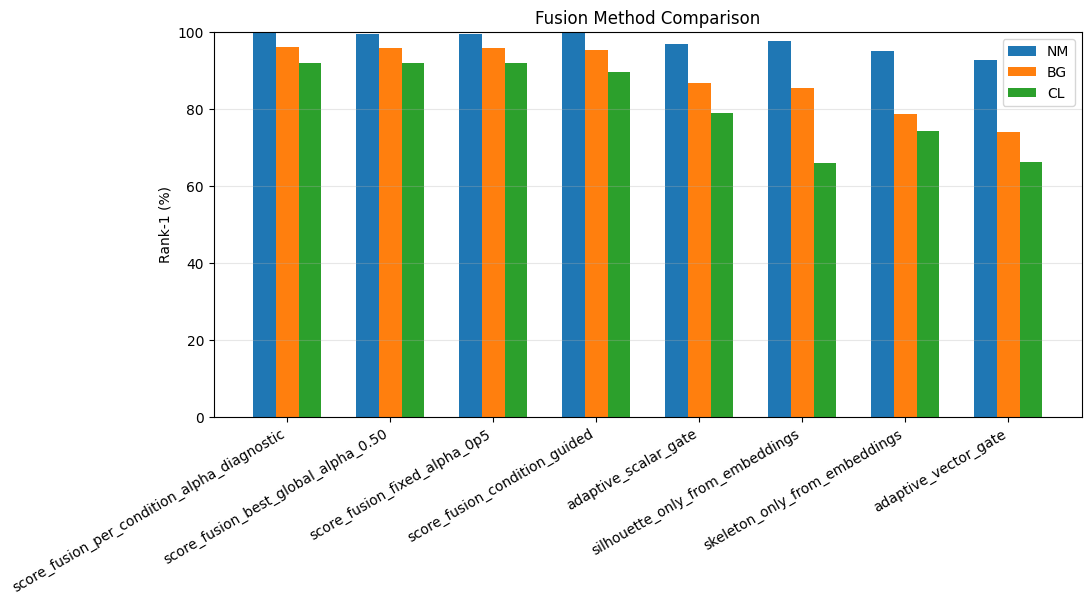

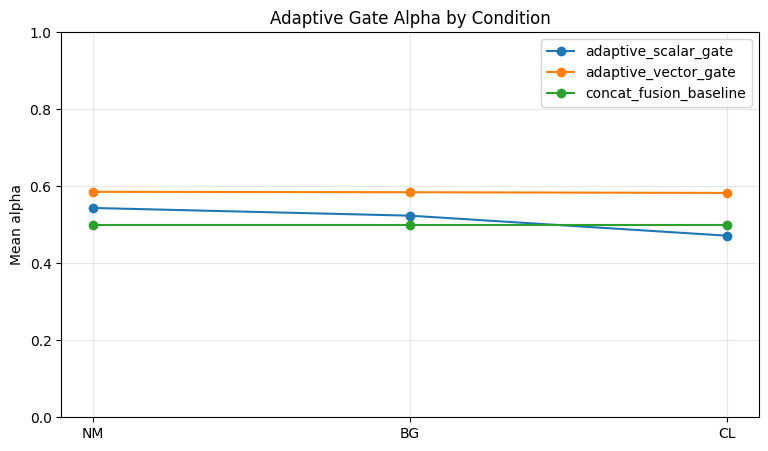

Best fusion summary:
{
  "best_stage": "score_fusion",
  "best_method": "score_fusion_per_condition_alpha_diagnostic",
  "best_mean_rank1_percent": 95.87878787878788,
  "best_NM_rank1_percent": 99.63636363636364,
  "best_BG_rank1_percent": 96.0909090909091,
  "best_CL_rank1_percent": 91.9090909090909,
  "all_results_csv": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/all_fusion_results_long.csv",
  "method_summary_csv": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/all_fusion_method_summary.csv",
  "comparison_plot": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/plots/fusion_method_comparison_rank1.png",
  "alpha_plot": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/plots/adaptive_gate_alpha_by_condition.png"
}
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/fusion_gate/best_fusion_summary.json


In [19]:
# ============================================================
# CELL 14 — Final comparison, plots, and best fusion selection
# ============================================================

all_result_tables = []

if "score_results_df" in globals() and isinstance(score_results_df, pd.DataFrame) and len(score_results_df) > 0:
    tmp = score_results_df.copy()
    tmp["stage"] = "score_fusion"
    all_result_tables.append(tmp)

if "trainable_results_df" in globals() and isinstance(trainable_results_df, pd.DataFrame) and len(trainable_results_df) > 0:
    tmp = trainable_results_df.copy()
    tmp["stage"] = "trainable_fusion"
    all_result_tables.append(tmp)

if all_result_tables:
    final_results = pd.concat(all_result_tables, ignore_index=True)

    method_summary = (
        final_results
        .groupby(["stage", "method"], as_index=False)
        .agg(mean_rank1_percent=("rank1_percent", "mean"))
        .sort_values("mean_rank1_percent", ascending=False)
        .reset_index(drop=True)
    )

    wide = final_results.pivot_table(
        index=["stage", "method"],
        columns="condition",
        values="rank1_percent",
        aggfunc="first",
    ).reset_index()

    method_summary = pd.merge(method_summary, wide, on=["stage", "method"], how="left")
    method_summary = method_summary.sort_values("mean_rank1_percent", ascending=False).reset_index(drop=True)

    final_results_csv = FUSION_ROOT / "all_fusion_results_long.csv"
    method_summary_csv = FUSION_ROOT / "all_fusion_method_summary.csv"

    final_results.to_csv(final_results_csv, index=False)
    method_summary.to_csv(method_summary_csv, index=False)

    print("All fusion method summary:")
    display(method_summary)

    best = method_summary.iloc[0].to_dict()

    top_methods = method_summary.head(min(8, len(method_summary))).copy()
    labels = top_methods["method"].astype(str).tolist()

    plt.figure(figsize=(max(10, len(labels) * 1.4), 5))
    x = np.arange(len(labels))
    width = 0.22

    for j, cond in enumerate(["NM", "BG", "CL"]):
        if cond in top_methods.columns:
            plt.bar(x + (j - 1) * width, top_methods[cond], width, label=cond)

    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel("Rank-1 (%)")
    plt.ylim(0, 100)
    plt.title("Fusion Method Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plot_path = PLOT_DIR / "fusion_method_comparison_rank1.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    if "alpha_analysis_df" in globals() and isinstance(alpha_analysis_df, pd.DataFrame) and len(alpha_analysis_df) > 0:
        probe_alpha = alpha_analysis_df[alpha_analysis_df["condition"].isin(["NM", "BG", "CL"])].copy()
        if len(probe_alpha) > 0:
            plt.figure(figsize=(9, 5))
            for model_name, g in probe_alpha.groupby("model"):
                plt.plot(g["condition"], g["alpha_mean"], marker="o", label=model_name)
            plt.ylabel("Mean alpha")
            plt.ylim(0, 1)
            plt.title("Adaptive Gate Alpha by Condition")
            plt.grid(True, alpha=0.3)
            plt.legend()
            alpha_plot = PLOT_DIR / "adaptive_gate_alpha_by_condition.png"
            plt.savefig(alpha_plot, dpi=150, bbox_inches="tight")
            plt.show()
        else:
            alpha_plot = ""
    else:
        alpha_plot = ""

    best_summary = {
        "best_stage": str(best.get("stage", "")),
        "best_method": str(best.get("method", "")),
        "best_mean_rank1_percent": float(best.get("mean_rank1_percent", np.nan)),
        "best_NM_rank1_percent": float(best.get("NM", np.nan)) if "NM" in best else np.nan,
        "best_BG_rank1_percent": float(best.get("BG", np.nan)) if "BG" in best else np.nan,
        "best_CL_rank1_percent": float(best.get("CL", np.nan)) if "CL" in best else np.nan,
        "all_results_csv": str(final_results_csv),
        "method_summary_csv": str(method_summary_csv),
        "comparison_plot": str(plot_path),
        "alpha_plot": str(alpha_plot),
    }

    best_summary_json = FUSION_ROOT / "best_fusion_summary.json"
    with open(best_summary_json, "w") as f:
        json.dump(best_summary, f, indent=2)

    print("Best fusion summary:")
    print(json.dumps(best_summary, indent=2))
    print("Saved:", best_summary_json)

else:
    print("No fusion results available. Check embedding availability.")

In [20]:
# ============================================================
# CELL 15 — Generate final report
# ============================================================

def df_to_markdown_simple(df):
    df2 = df.copy()

    def fmt(x):
        if pd.isna(x):
            return ""
        if isinstance(x, float):
            return f"{x:.4f}"
        return str(x)

    cols = [str(c) for c in df2.columns]
    lines = []
    lines.append("| " + " | ".join(cols) + " |")
    lines.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for row in df2.to_numpy():
        cells = [fmt(v).replace("|", "\\|") for v in row]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)

report = []
report.append("# Adaptive Fusion Gate Report")
report.append("")
report.append(f"Experiment directory: `{EXP_DIR}`")
report.append("")
report.append("## Available embeddings")
report.append("")
for expert in ["skeleton", "silhouette"]:
    report.append(f"- {expert}: `{list(available_embs.get(expert, {}).keys())}`")
report.append("")

if "method_summary" in globals() and isinstance(method_summary, pd.DataFrame) and len(method_summary) > 0:
    report.append("## Fusion method summary")
    report.append("")
    report.append(df_to_markdown_simple(method_summary))
    report.append("")
    report.append("## Best method")
    report.append("")
    report.append(f"- Best method: `{best_summary['best_method']}`")
    report.append(f"- Mean Rank-1: `{best_summary['best_mean_rank1_percent']:.4f}%`")
    report.append(f"- NM Rank-1: `{best_summary['best_NM_rank1_percent']:.4f}%`")
    report.append(f"- BG Rank-1: `{best_summary['best_BG_rank1_percent']:.4f}%`")
    report.append(f"- CL Rank-1: `{best_summary['best_CL_rank1_percent']:.4f}%`")
else:
    report.append("No final fusion result was produced. Usually this means paired skeleton/silhouette embeddings were missing.")

if "alpha_analysis_df" in globals() and isinstance(alpha_analysis_df, pd.DataFrame) and len(alpha_analysis_df) > 0:
    report.append("")
    report.append("## Gate alpha analysis")
    report.append("")
    report.append(df_to_markdown_simple(alpha_analysis_df))

report_path = FUSION_ROOT / "adaptive_fusion_report.md"
report_path.write_text("\n".join(report), encoding="utf-8")

print("\n".join(report))
print("Saved:", report_path)

# Adaptive Fusion Gate Report

Experiment directory: `/media/wadud/DriveUbuntu/GaitRecognition 2.0`

## Available embeddings

- skeleton: `['train', 'gallery', 'NM', 'BG', 'CL']`
- silhouette: `['train', 'gallery', 'NM', 'BG', 'CL']`

## Fusion method summary

| stage | method | mean_rank1_percent | BG | CL | NM |
| --- | --- | --- | --- | --- | --- |
| score_fusion | score_fusion_per_condition_alpha_diagnostic | 95.8788 | 96.0909 | 91.9091 | 99.6364 |
| score_fusion | score_fusion_best_global_alpha_0.50 | 95.7273 | 95.9091 | 91.9091 | 99.3636 |
| score_fusion | score_fusion_fixed_alpha_0p5 | 95.7273 | 95.9091 | 91.9091 | 99.3636 |
| score_fusion | score_fusion_condition_guided | 94.8788 | 95.4545 | 89.5455 | 99.6364 |
| trainable_fusion | adaptive_scalar_gate | 87.5152 | 86.8182 | 78.9091 | 96.8182 |
| score_fusion | silhouette_only_from_embeddings | 82.9697 | 85.4545 | 65.9091 | 97.5455 |
| score_fusion | skeleton_only_from_embeddings | 82.6061 | 78.6364 | 74.1818 | 95.0000 |
| train

## How to interpret the output

Best practical result:

```text
all_fusion_method_summary.csv
```

Key methods:

```text
skeleton_only_from_embeddings
silhouette_only_from_embeddings
score_fusion_fixed_alpha_0p5
score_fusion_condition_guided
score_fusion_best_global_alpha_*
score_fusion_per_condition_alpha_diagnostic
concat_fusion_baseline
adaptive_scalar_gate
adaptive_vector_gate
```

For research reporting:

- `score_fusion_per_condition_alpha_diagnostic` is diagnostic/oracle-like, because it uses test condition results to choose alpha.
- `concat_fusion_baseline` is a weak trainable fusion baseline.
- `adaptive_scalar_gate` and `adaptive_vector_gate` are the proposed fusion versions.
- Use `adaptive_gate_alpha_analysis.csv` to show whether alpha changes across NM/BG/CL.